<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [376]:
#Importation de la librairie Pandas
import pandas as pd
#Importation des librairies numpy et matplotlib
import numpy as np
import matplotlib.pyplot as plt


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers CSV</h3>
</div>

In [377]:
#Importation du fichier population.csv
population = pd.read_csv('data/population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alim = pd.read_csv('data/dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alim = pd.read_csv('data/aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('data/sous_nutrition.csv')

for name, df in [("population", population), ("dispo", dispo_alim), ("aide", aide_alim), ("sous_nut", sous_nutrition)]:
    print(name, df.shape)



population (1416, 3)
dispo (15605, 18)
aide (1475, 4)
sous_nut (1218, 3)


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [378]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [379]:
#Consulter le nombre de colonnes
population.shape[1]
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))
#La nature des données dans chacune des colonnes
population.info()
#Le nombre de valeurs présentes dans chacune des colonnes
population.count()


Le tableau comporte 3 colonne(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB


Zone      1416
Année     1416
Valeur    1416
dtype: int64

In [380]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [381]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population.columns
population["Valeur"].head()
population["population_habitants"] = population["Valeur"] * 1000
population.head()

,Zone,Année,Valeur,population_habitants
0,Afghanistan,2013,32269.589,32269589.0
1,Afghanistan,2014,33370.794,33370794.0
2,Afghanistan,2015,34413.603,34413603.0
3,Afghanistan,2016,35383.032,35383032.0
4,Afghanistan,2017,36296.113,36296113.0


In [382]:
#changement du nom de la colonne Valeur par Population
population = population.rename(columns={"Valeur": "Population"})
population.columns

Index(['Zone', 'Année', 'Population', 'population_habitants'], dtype='object')

In [383]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population,population_habitants
0,Afghanistan,2013,32269.589,32269589.0
1,Afghanistan,2014,33370.794,33370794.0
2,Afghanistan,2015,34413.603,34413603.0
3,Afghanistan,2016,35383.032,35383032.0
4,Afghanistan,2017,36296.113,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [384]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alim.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alim.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [385]:
#Consulter le nombre de colonnes
dispo_alim.shape[1]
print("Le tableau comporte {} colonne(s)".format(dispo_alim.shape[1]))

Le tableau comporte 18 colonne(s)


In [386]:
#Affichage les 5 premières lignes de la table
dispo_alim.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [451]:
#remplacement des NaN dans le dataset par des 0
dispo_alim = dispo_alim.fillna(0)
population.isna().sum()


Zone                    0
Année                   0
Population              0
population_habitants    0
dtype: int64

In [388]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
dispo_alim.columns
for col in dispo_alim.columns:
    print(col)
    colonnes_milliers_tonnes = [
    "Autres Utilisations",
    "Disponibilité intérieure",
    "Exportations - Quantité",
    "Importations - Quantité",
    "Nourriture",
    "Pertes",
    "Production",
    "Semences",
    "Traitement",
    "Variation de stock"
]

for col in colonnes_milliers_tonnes:
    dispo_alim[col + "_kg"] = dispo_alim[col] * 1_000_000

dispo_alim[["Production", "Production_kg"]].head()


Zone
Produit
Origine
Aliments pour animaux
Autres Utilisations
Disponibilité alimentaire (Kcal/personne/jour)
Disponibilité alimentaire en quantité (kg/personne/an)
Disponibilité de matière grasse en quantité (g/personne/jour)
Disponibilité de protéines en quantité (g/personne/jour)
Disponibilité intérieure
Exportations - Quantité
Importations - Quantité
Nourriture
Pertes
Production
Semences
Traitement
Variation de stock


,Production,Production_kg
0,53.0,53000000.0
1,3.0,3000000.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [389]:
#Affichage les 5 premières lignes de la table
dispo_alim.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Autres Utilisations_kg,Disponibilité intérieure_kg,Exportations - Quantité_kg,Importations - Quantité_kg,Nourriture_kg,Pertes_kg,Production_kg,Semences_kg,Traitement_kg,Variation de stock_kg
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,...,0.0,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,...,0.0,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,...,0.0,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,...,0.0,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [390]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alim.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alim.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [391]:
#Consulter le nombre de colonnes
aide_alim.shape[1]
print("Le tableau comporte {} colonne(s)".format(aide_alim.shape[1]))

Le tableau comporte 4 colonne(s)


In [392]:
#Affichage les 5 premières lignes de la table
aide_alim.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [393]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alim = aide_alim.rename(columns={"Pays bénéficiaire": "Zone"})
aide_alim.columns

Index(['Zone', 'Année', 'Produit', 'Valeur'], dtype='object')

In [394]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alim.columns
for col in aide_alim.columns:
    print(col)
    colonnes_milliers_tonnes = [
    "Valeur",
]

for col in colonnes_milliers_tonnes:
    aide_alim[col + "_kg"] = aide_alim[col] * 1_000_000

aide_alim[["Valeur", "Valeur_kg"]].head()

Zone
Année
Produit
Valeur


,Valeur,Valeur_kg
0,682,682000000
1,335,335000000
2,39224,39224000000
3,15160,15160000000
4,40504,40504000000


In [395]:
#Affichage les 5 premières lignes de la table
aide_alim.head()

,Zone,Année,Produit,Valeur,Valeur_kg
0,Afghanistan,2013,Autres non-céréales,682,682000000
1,Afghanistan,2014,Autres non-céréales,335,335000000
2,Afghanistan,2013,Blé et Farin,39224,39224000000
3,Afghanistan,2014,Blé et Farin,15160,15160000000
4,Afghanistan,2013,Céréales,40504,40504000000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [396]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [397]:
#Consulter le nombre de colonnes
sous_nutrition.shape[1]
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 3 colonne(s)


In [398]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [399]:
#Conversion de la colonne sous nutrition en numérique
sous_nutrition["Valeur"] = pd.to_numeric(
    sous_nutrition["Valeur"],
    errors="coerce"
)
sous_nutrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1218 non-null   object 
 1   Année   1218 non-null   object 
 2   Valeur  504 non-null    float64
dtypes: float64(1), object(2)
memory usage: 28.7+ KB


In [400]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition["Valeur"] = sous_nutrition["Valeur"].fillna(0)
sous_nutrition.info()

sous_nutrition["Valeur"].isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1218 non-null   object 
 1   Année   1218 non-null   object 
 2   Valeur  1218 non-null   float64
dtypes: float64(1), object(2)
memory usage: 28.7+ KB


np.int64(0)

In [401]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition = sous_nutrition.rename(columns={"Valeur": "sous_nutrition"})
sous_nutrition.columns

Index(['Zone', 'Année', 'sous_nutrition'], dtype='object')

In [402]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition["sous_nutrition"] = sous_nutrition["sous_nutrition"] * 1_000_000

In [403]:
#Afficher les 5 premières lignes de la table
sous_nutrition["sous_nutrition"].head()


0     8600000.0
1     8800000.0
2     8900000.0
3     9700000.0
4    10500000.0
Name: sous_nutrition, dtype: float64

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [431]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
print(population.columns)
print(sous_nutrition.columns)
population_2017 = population[population["Année"] == 2017].copy()
population_2017["Année"].unique()
sous_nutrition["annee_centrale"] = (
    sous_nutrition["Année"].astype(str).str[:4].astype(int) + 1
)
sous_nutrition[["Année", "annee_centrale"]].head()
sous_nutrition_2017 = sous_nutrition[
    sous_nutrition["annee_centrale"] == 2017
].copy()
sous_nutrition_2017["annee_centrale"].unique()
df_2017 = population_2017.merge(
    sous_nutrition_2017[["Zone", "sous_nutrition"]],
    on="Zone",
    how="left"
)
df_2017.head()
df_2017.info()


Index(['Zone', 'Année', 'Population', 'population_habitants'], dtype='object')
Index(['Zone', 'Année', 'sous_nutrition', 'annee_centrale'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Zone                  236 non-null    object 
 1   Année                 236 non-null    int64  
 2   Population            236 non-null    float64
 3   population_habitants  236 non-null    float64
 4   sous_nutrition        203 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 9.3+ KB


In [432]:
#Affichage du dataset
df_2017.head()


,Zone,Année,Population,population_habitants,sous_nutrition
0,Afghanistan,2017,36296.113,36296113.0,10500000.0
1,Afrique du Sud,2017,57009.756,57009756.0,3100000.0
2,Albanie,2017,2884.169,2884169.0,100000.0
3,Algérie,2017,41389.189,41389189.0,1300000.0
4,Allemagne,2017,82658.409,82658409.0,0.0


In [433]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
# Nombre total de personnes en sous-nutrition en 2017
total_sous_nutrition = df_2017["sous_nutrition"].sum()

# Population mondiale en personnes
population_mondiale = df_2017["Population"].sum() * 1000

# Part de la population mondiale sous-alimentée (en %)
part_sous_nutrition = (total_sous_nutrition / population_mondiale) * 100

print("Nombre total de personnes en état de sous-nutrition en 2017 :", int(total_sous_nutrition))
print(f"Part de la population mondiale sous-alimentée : {part_sous_nutrition:.2f} %")

Nombre total de personnes en état de sous-nutrition en 2017 : 535700000
Part de la population mondiale sous-alimentée : 7.10 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [407]:
#Combien mange en moyenne un être humain ? Source =>
# Hypothèse : consommation moyenne journalière par personne (en kcal)
#Cette valeur correspond à une estimation de référence utilisée par la FAO et l’OMS pour des analyses globales de sécurité alimentaire.
conso_moyenne_kcal = 2500

In [408]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
population_2017 = population[population["Année"] == 2017].copy()
population_2017["Année"].unique()
dispo_alim.columns


dispo_alim_2017 = dispo_alim.merge(
    population_2017[["Zone", "Population"]],
    on="Zone",
    how="left"
)
dispo_alim_2017.head()
dispo_alim_2017["Population"] = dispo_alim_2017["Population"] * 1000



In [409]:
#Affichage du nouveau dataframe
dispo_alim_2017.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Disponibilité intérieure_kg,Exportations - Quantité_kg,Importations - Quantité_kg,Nourriture_kg,Pertes_kg,Production_kg,Semences_kg,Traitement_kg,Variation de stock_kg,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,...,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,...,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,...,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,...,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0


In [434]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
dispo_alim_2017["Population"].head()

dispo_alim_2017["dispo_kcal"] = (
    dispo_alim_2017["Disponibilité alimentaire (Kcal/personne/jour)"]
    * dispo_alim_2017["Population"]
)
dispo_alim_2017.head()


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Exportations - Quantité_kg,Importations - Quantité_kg,Nourriture_kg,Pertes_kg,Production_kg,Semences_kg,Traitement_kg,Variation de stock_kg,Population,dispo_kcal
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,...,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,36296113.0,181480565.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,...,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,...,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,...,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,145184452.0


In [411]:
#Calcul du nombre d'humains pouvant être nourris
# Calcul du nombre de personnes pouvant être nourries
kcal_totales_monde = dispo_alim_2017["dispo_kcal"].sum()
personnes_nourries_monde = kcal_totales_monde / conso_moyenne_kcal
print(f"Nombre théorique de personnes pouvant être nourries en 2017 : {personnes_nourries_monde:,.0f}")



Nombre théorique de personnes pouvant être nourries en 2017 : 8,367,593,851


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [412]:
#Transfert des données avec les végétaux dans un nouveau dataframe
dispo_vegetaux = dispo_alim_2017[dispo_alim_2017["Origine"] == "vegetale"].copy()
dispo_vegetaux["Origine"].unique()
dispo_vegetaux.head()


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Exportations - Quantité_kg,Importations - Quantité_kg,Nourriture_kg,Pertes_kg,Production_kg,Semences_kg,Traitement_kg,Variation de stock_kg,Population,dispo_kcal
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,...,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,...,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,...,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,145184452.0
6,Afghanistan,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,0.00,3.0,...,0.0,3000000.0,3000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.0


In [413]:
#Calcul du nombre de kcal disponible pour les végétaux
total_kcal_vegetaux = dispo_vegetaux["dispo_kcal"].sum()

# Affichage du résultat
print(f"Nombre total de kcal disponibles pour les végétaux : {total_kcal_vegetaux:,.0f}")

Nombre total de kcal disponibles pour les végétaux : 17,260,764,211,501


In [414]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
personnes_nourries_vegetaux = total_kcal_vegetaux / conso_moyenne_kcal

# Affichage du résultat
print(
    f"Nombre théorique de personnes pouvant être nourries uniquement avec les végétaux : {personnes_nourries_vegetaux:,.0f}"
)

Nombre théorique de personnes pouvant être nourries uniquement avec les végétaux : 6,904,305,685


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [415]:
#Calcul de la disponibilité totale
usages = [
    "Nourriture",
    "Aliments pour animaux",
    "Pertes",
    "Semences",
    "Traitement",
    "Autres Utilisations"
]

# Totaux mondiaux (en milliers de tonnes)
totaux_usages = dispo_alim_2017[usages].sum().sort_values(ascending=False)
totaux_usages
total_usages = totaux_usages.sum()
parts_usages = (totaux_usages / total_usages) * 100
parts_usages
for col, pct in parts_usages.items():
    print(f"{col} : {pct:.2f} %")
# Disponibilité intérieure ≈ somme des usages
total_dispo_interieure = dispo_alim_2017["Disponibilité intérieure"].sum()
somme_usages = dispo_alim_2017[usages].sum().sum()

print(f"Disponibilité intérieure totale (kt) : {total_dispo_interieure:,.0f}")
print(f"Somme des usages (kt) : {somme_usages:,.0f}")
print(f"Écart (kt) : {(total_dispo_interieure - somme_usages):,.0f}")

Nourriture : 49.46 %
Traitement : 22.36 %
Aliments pour animaux : 13.23 %
Autres Utilisations : 8.77 %
Pertes : 4.60 %
Semences : 1.57 %
Disponibilité intérieure totale (kt) : 9,848,994
Somme des usages (kt) : 9,858,592
Écart (kt) : -9,598


Nourriture : 49.46 %
Aliments pour animaux : 13.23 %
Pertes : 4.60 %
Semences : 1.57 %
Traitement : 22.36 %
Autres Utilisations : 8.77 %


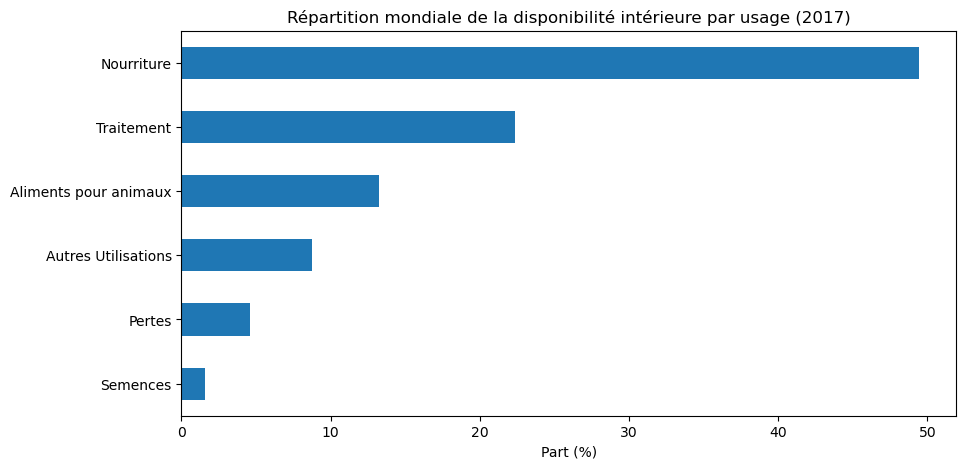

In [435]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 
# Liste des colonnes à analyser
colonnes_analyse = [
    "Nourriture",
    "Aliments pour animaux",
    "Pertes",
    "Semences",
    "Traitement",
    "Autres Utilisations"
]
#calcul des totaux et des parts
totaux = dispo_alim_2017[colonnes_analyse].sum()
total_general = totaux.sum()

parts = (totaux / total_general) * 100

for col in colonnes_analyse:
    print(f"{col} : {parts[col]:.2f} %")
#graphique qui accompagne les chiffres 
plt.figure(figsize=(10, 5))
parts.sort_values().plot(kind="barh")
plt.xlabel("Part (%)")
plt.title("Répartition mondiale de la disponibilité intérieure par usage (2017)")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [417]:
#Création d'une liste avec toutes les variables
liste_cereales = [
    "Blé",
    "Riz (Eq Blanchi)",
    "Orge",
    "Maïs",
    "Seigle",
    "Avoine",
    "Millet",
    "Sorgho",
    "Céréales, Autres"
]


    

In [418]:
#Création d'un dataframe avec les informations uniquement pour ces céréales

dispo_cereales = dispo_alim_2017[
    dispo_alim_2017["Produit"].isin(liste_cereales)
].copy()

# Vérification des produits présents
dispo_cereales["Produit"].unique()

array(['Blé', 'Céréales, Autres', 'Maïs', 'Millet', 'Orge',
       'Riz (Eq Blanchi)', 'Avoine', 'Seigle', 'Sorgho'], dtype=object)

In [419]:
#Affichage de la proportion d'alimentation animale
total_humain = dispo_cereales["Nourriture"].sum()
print(f"Quantité totale de céréales pour l'alimentation humaine : {total_humain:,.0f}")
total_animal = dispo_cereales["Aliments pour animaux"].sum()
print(f"Quantité totale de céréales pour l'alimentation animale : {total_animal:,.0f}")


Quantité totale de céréales pour l'alimentation humaine : 1,029,010
Quantité totale de céréales pour l'alimentation animale : 873,535


In [420]:
#Affichage de la proportion d'alimentation animale
total_reference = total_humain + total_animal
total_reference
part_humain = (total_humain / total_reference) * 100
part_animal = (total_animal / total_reference) * 100

print(f"Proportion des céréales pour l'alimentation humaine : {part_humain:.2f} %")
print(f"Proportion des céréales pour l'alimentation animale : {part_animal:.2f} %")


Proportion des céréales pour l'alimentation humaine : 54.09 %
Proportion des céréales pour l'alimentation animale : 45.91 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [421]:
#Création de la colonne proportion par pays
# Création de la colonne proportion de personnes sous-alimentées par pays
df_2017["Population_personnes"] = df_2017["Population"] * 1000
df_2017["proportion_sous_alimentee"] = (
    df_2017["sous_nutrition"] / df_2017["Population_personnes"]
) * 100


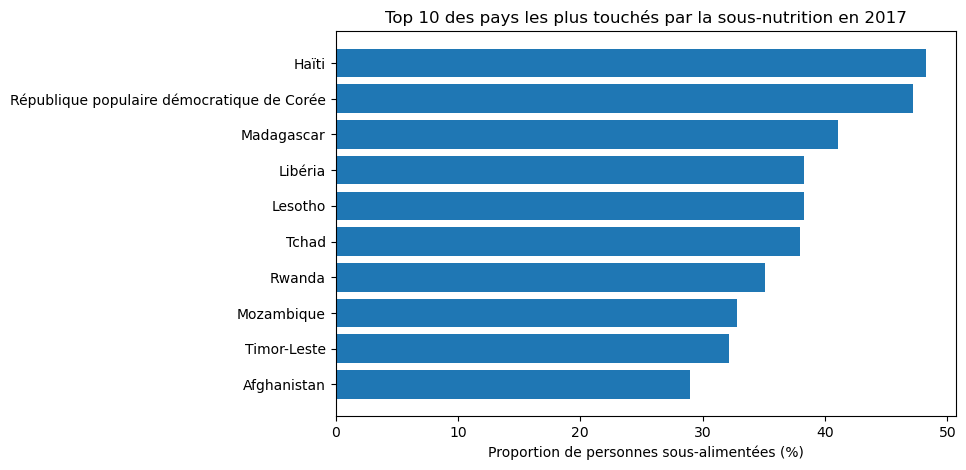

In [422]:
#affichage après trie des 10 pires pays
# Tri des pays par proportion de personnes sous-alimentées (ordre décroissant)
top_10_pires_pays = df_2017.sort_values(
    by="proportion_sous_alimentee",
    ascending=False
).head(10)
plt.figure(figsize=(8,5))

plt.barh(
    top_10_pires_pays["Zone"],
    top_10_pires_pays["proportion_sous_alimentee"]
)

plt.xlabel("Proportion de personnes sous-alimentées (%)")
plt.title("Top 10 des pays les plus touchés par la sous-nutrition en 2017")

# Inverser l’axe pour avoir le pire pays en haut
plt.gca().invert_yaxis()

plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [423]:
#calcul du total de l'aide alimentaire par pays
# Filtrage entre 2013 et 2016
aide_2013_2016 = aide_alim[
    (aide_alim["Année"] >= 2013) & (aide_alim["Année"] <= 2016)
].copy()

# Total d'aide alimentaire par pays (en milliers de tonnes)
aide_par_pays = (
    aide_2013_2016
    .groupby("Zone")["Valeur"]
    .sum()
    .reset_index()
)


In [436]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
# Affichage des 10 pays les plus aidés
top_aide_pays = aide_par_pays.sort_values(
    by="Valeur",
    ascending=False
).head(10)

top_aide_pays

,Zone,Valeur
50,République arabe syrienne,1858943
75,Éthiopie,1381294
70,Yémen,1206484
61,Soudan du Sud,695248
60,Soudan,669784
30,Kenya,552836
3,Bangladesh,348188
59,Somalie,292678
53,République démocratique du Congo,288502
43,Niger,276344


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [441]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
# Filtrage des données entre 2013 et 2016
aide_2013_2016 = aide_alim[
    (aide_alim["Année"] >= 2013) & (aide_alim["Année"] <= 2016)
].copy()

# Total de l'aide alimentaire par pays sur la période
top_5_pays = (
    aide_2013_2016
    .groupby("Zone")["Valeur"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)
# Création d'un DataFrame avec Zone, Année et aide alimentaire
evolution_aide = (
    aide_2013_2016[aide_2013_2016["Zone"].isin(top_5_pays)]
    .groupby(["Zone", "Année"])["Valeur"]
    .sum()
    .reset_index()
)

In [442]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
liste_top_5_pays = top_5_pays.tolist()

# Affichage de la liste
liste_top_5_pays

['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

In [443]:
#On filtre sur le dataframe avec notre liste
aide_top_5 = aide_2013_2016[
    aide_2013_2016["Zone"].isin(liste_top_5_pays)
].copy()
aide_top_5["Zone"].unique()

array(['Éthiopie', 'République arabe syrienne', 'Soudan', 'Soudan du Sud',
       'Yémen'], dtype=object)

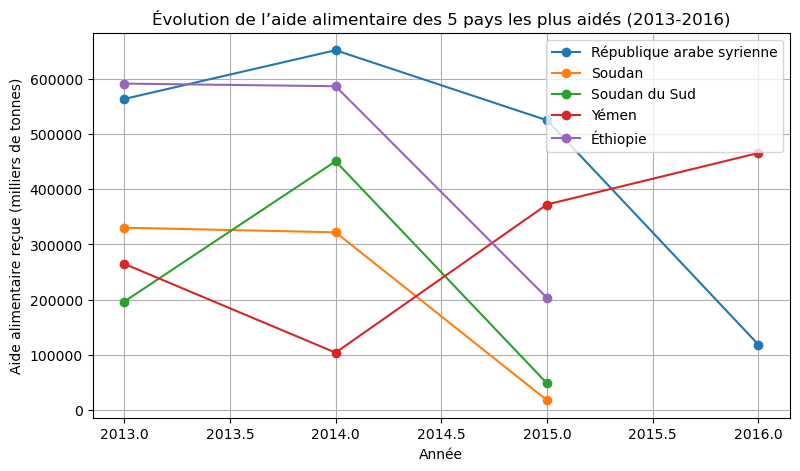

In [444]:
# Affichage des pays avec l'aide alimentaire par année

plt.figure(figsize=(9,5))

for pays in evolution_aide["Zone"].unique():
    data_pays = evolution_aide[evolution_aide["Zone"] == pays]
    plt.plot(data_pays["Année"], data_pays["Valeur"], marker="o", label=pays)

plt.xlabel("Année")
plt.ylabel("Aide alimentaire reçue (milliers de tonnes)")
plt.title("Évolution de l’aide alimentaire des 5 pays les plus aidés (2013-2016)")
plt.legend()
plt.grid(True)

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [447]:
#Calcul de la disponibilité en kcal par personne par jour par pays
kcal_par_pays = (
    dispo_alim_2017
    .groupby("Zone")
    .agg(
        dispo_kcal=("dispo_kcal", "sum"),
        Population=("Population", "first")
    )
    .reset_index()
)
# Calcul de la disponibilité en kcal par personne et par jour
kcal_par_pays["kcal_par_personne_par_jour"] = (
    kcal_par_pays["dispo_kcal"] / kcal_par_pays["Population"]
)
kcal_par_pays.head()

,Zone,dispo_kcal,Population,kcal_par_personne_par_jour
0,Afghanistan,7.574999e+10,36296113.0,2087.0
1,Afrique du Sud,1.721695e+11,57009756.0,3020.0
2,Albanie,9.194731e+09,2884169.0,3188.0
3,Algérie,1.362946e+11,41389189.0,3293.0
4,Allemagne,2.895524e+11,82658409.0,3503.0


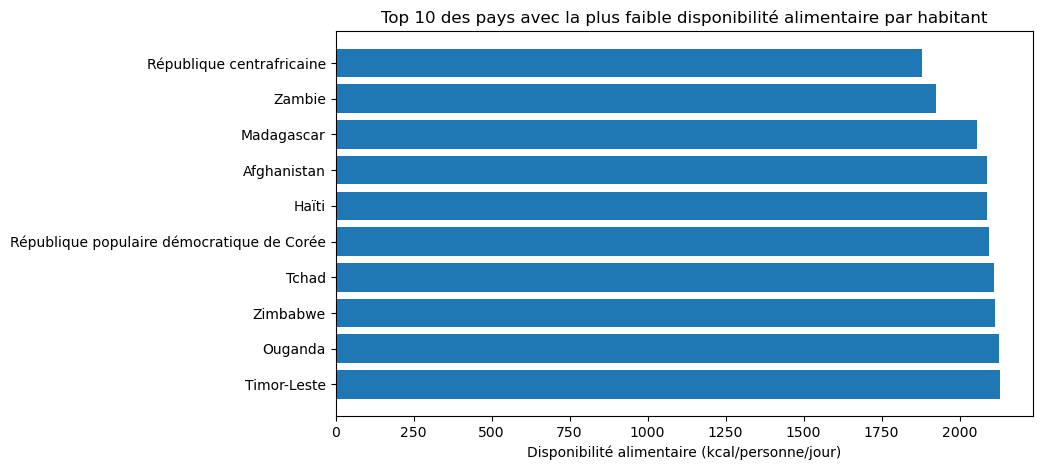

In [448]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
pays_moins_dispo = kcal_par_pays.sort_values("kcal_par_personne_par_jour").head(10)

plt.figure(figsize=(9,5))

plt.barh(
    pays_moins_dispo["Zone"],
    pays_moins_dispo["kcal_par_personne_par_jour"]
)

plt.xlabel("Disponibilité alimentaire (kcal/personne/jour)")
plt.title("Top 10 des pays avec la plus faible disponibilité alimentaire par habitant")
plt.gca().invert_yaxis()

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

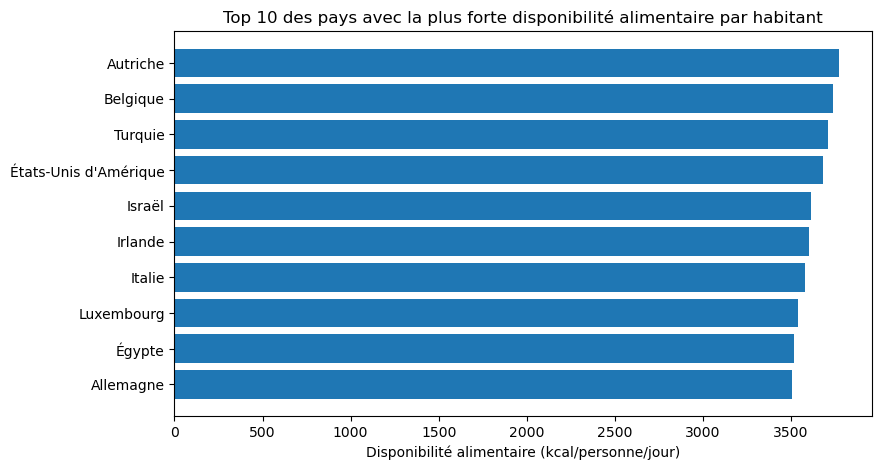

In [450]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
pays_plus_dispo = kcal_par_pays.sort_values("kcal_par_personne_par_jour",ascending=False
).head(10)
plt.figure(figsize=(9,5))

plt.barh(
    pays_plus_dispo["Zone"],
    pays_plus_dispo["kcal_par_personne_par_jour"]
)

plt.xlabel("Disponibilité alimentaire (kcal/personne/jour)")
plt.title("Top 10 des pays avec la plus forte disponibilité alimentaire par habitant")
plt.gca().invert_yaxis()

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [ ]:
#création d'un dataframe avec uniquement la Thaïlande 
dispo_thailande = dispo_alim_2017[
    dispo_alim_2017["Zone"] == "Thaïlande"
].copy()
dispo_thailande["Zone"].unique()

In [ ]:
#Calcul de la sous nutrition en Thaïlande
sous_nutrition_thailande = df_2017.loc[
    df_2017["Zone"] == "Thaïlande",
    "sous_nutrition"
].values[0]

print(
    f"Nombre de personnes sous-alimentées en Thaïlande : {sous_nutrition_thailande:,.0f}"
)
population_thailande = df_2017.loc[
    df_2017["Zone"] == "Thaïlande",
    "Population"
].values[0] * 1000  

proportion_sous_nut_thai = (
    sous_nutrition_thailande / population_thailande * 100
)

print(f"Part de la population sous-alimentée en Thaïlande : {proportion_sous_nut_thai:.2f} %")
# Disponibilité alimentaire de la Thaïlande 

# Filtrer la Thaïlande dans le dataset de disponibilité alimentaire 2017
dispo_thailande = dispo_alim_2017[dispo_alim_2017["Zone"] == "Thaïlande"]

# Somme des kcal disponibles en Thaïlande
total_kcal_thailande = dispo_thailande["dispo_kcal"].sum()

# Disponibilité alimentaire par personne et par jour
kcal_par_personne_thailande = total_kcal_thailande / population_thailande

print(f"Disponibilité alimentaire totale en Thaïlande : {total_kcal_thailande:,.0f} kcal/jour")
print(f"Disponibilité alimentaire par personne en Thaïlande : {kcal_par_personne_thailande:,.0f} kcal/personne/jour")


In [445]:
# On calcule la proportion exportée en fonction de la proportion
# Filtrage du manioc pour la Thaïlande
dispo_thai_manioc = dispo_thailande[
    dispo_thailande["Produit"] == "Manioc"
].copy()
dispo_thai_manioc[[
    "Zone",
    "Produit",
    "Production",
    "Exportations - Quantité",
    "Disponibilité intérieure"
]]
# Production totale de manioc (en milliers de tonnes)
production_manioc = dispo_thai_manioc["Production"].sum()

# Exportations totales de manioc (en milliers de tonnes)
export_manioc = dispo_thai_manioc["Exportations - Quantité"].sum()

production_manioc, export_manioc
# Calcul de la proportion exportée
proportion_exportee = export_manioc / production_manioc

print(
    f"Proportion du manioc exportée par la Thaïlande : {proportion_exportee*100:.2f} %"
)

Proportion du manioc exportée par la Thaïlande : 83.41 %


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

#ajouter en dessous toutes les analyses complémentaires
<div >
<p1>L’analyse de la situation en Syrie met en évidence l’impact des conflits armés sur la sécurité alimentaire.
La forte augmentation de l’aide alimentaire à partir de 2013 reflète la dégradation des conditions de vie et la désorganisation du système agricole et logistique du pays.

Cette situation montre que la faim n’est pas uniquement liée à un manque de production, mais surtout à des difficultés d’accès à la nourriture, causées par l’instabilité politique, les déplacements de population et la destruction des infrastructures.</p2>
</div>


In [ ]:
# Filtrer les données d'aide alimentaire pour la Syrie
aide_syrie = aide_alim[aide_alim["Zone"] == "République arabe syrienne"]

# Aide totale par année
aide_syrie_par_an = aide_syrie.groupby("Année")["Valeur"].sum()

print(aide_syrie_par_an)


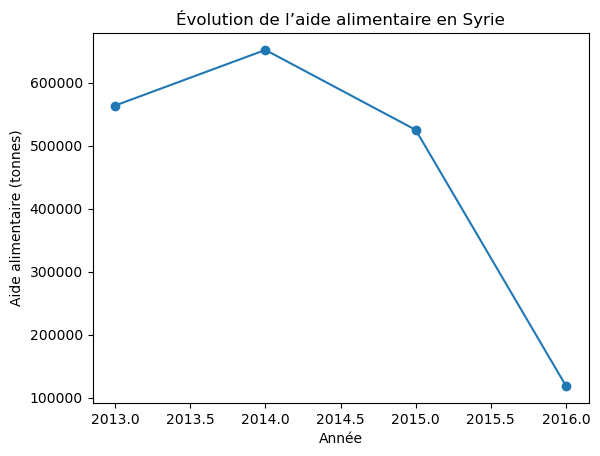

In [446]:
aide_syrie_par_an.plot(kind="line", marker="o", title="Évolution de l’aide alimentaire en Syrie")
plt.ylabel("Aide alimentaire (tonnes)")
plt.show()
